<a href="https://colab.research.google.com/github/mamoor2019/DeepFER/blob/MyRepositery/DeepFacialEmotionRecognition_mamoor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - DeepFER: Facial Emotion Recognition Using Deep Learning



##### **Project Type**    - Deep Learning
##### **Contribution**    - Individual
##### **Submitted by -** Mohammad Mamoor Ahmad

# **Project Summary -**

**DeepFER (Facial Emotion Recognition Using Deep Learning)** is a computer vision and deep learning project focused on automatically recognizing human emotions from facial expressions. The system uses Convolutional Neural Networks (CNNs) and Transfer Learning to classify facial images into seven emotion categories: Angry, Sad, Happy, Fear, Neutral, Disgust, and Surprise.

The project involved comprehensive image preprocessing, data augmentation, model development, training, and evaluation to improve model robustness and generalization across different facial appearances, lighting conditions, and expressions. Techniques such as rotation, scaling, and flipping were used to increase training-data diversity, while transfer learning enabled the use of knowledge learned from pre-trained deep learning models.

Model performance was evaluated using metrics including accuracy, precision, recall, and F1-score, with an emphasis on developing an efficient model capable of supporting real-time emotion recognition from images or video streams.

The project demonstrates the application of deep learning, CNNs, computer vision, transfer learning, and image classification to build intelligent systems that can interpret facial expressions. Potential applications include human-computer interaction, customer experience analysis, virtual assistants, and other interactive AI systems.

**Key Technologies & Techniques**
* Deep Learning & Computer Vision
* Convolutional Neural Networks (CNN)
* Transfer Learning & Fine-Tuning
* Image Classification
* Data Augmentation
* Image Preprocessing
* Model Evaluation: Accuracy, Precision, Recall, F1-score
* Real-Time Facial Emotion Recognition

# **GitHub Link -**

https://github.com/mamoor2019/DeepFER

# **Problem Statement**


Accurately recognizing human emotions from facial expressions is a challenging computer vision problem because facial expressions can vary significantly across individuals, lighting conditions, facial poses, backgrounds, and levels of expression. Traditional emotion recognition approaches often depend on manually engineered facial features and predefined rules, which can have limited ability to generalize to diverse and real-world images.

The problem addressed by DeepFER(Facial Emotion Recognition Using Deep Learning) is to develop an automated and reliable system that can identify human emotions directly from facial images. The system must classify facial expressions into seven emotion categories: Angry, Sad, Happy, Fear, Neutral, Disgust, and Surprise.

To address this problem, the project uses Convolutional Neural Networks (CNNs) and Transfer Learning to automatically learn meaningful facial features from images. Data augmentation techniques such as rotation, scaling, and flipping are used to increase data diversity and improve the model's ability to generalize to unseen images.

The developed system should achieve reliable classification performance while being computationally efficient enough to support real-time emotion recognition. The solution is intended to provide a foundation for applications such as human-computer interaction, customer service, virtual assistants, and other systems requiring automated interpretation of facial expressions.


# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
# Basic libraries
import os
import cv2
import random
import warnings
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning libraries
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

# Data splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

### Dataset Loading

In [2]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Load Dataset
dataset_path = "/content/drive/MyDrive/DeepFacialEmotionRecognition/FaceEmotionRecognitionDataset/images/train"

In [4]:
# Verify Emotion Classes
emotion_classes = os.listdir(dataset_path)

print("Emotion Classes:\n")

for emotion in emotion_classes:
    print(emotion)

Emotion Classes:

sad
neutral
fear
surprise
happy
disgust
angry


### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count

image_count = {}

for emotion in emotion_classes:

    folder_path = os.path.join(dataset_path, emotion)

    image_count[emotion] = len(os.listdir(folder_path))

image_count

{'sad': 4939,
 'neutral': 4982,
 'fear': 4103,
 'surprise': 3205,
 'happy': 7164,
 'disgust': 436,
 'angry': 3993}

### Dataset Summary Table

In [6]:
# Create Dataset Summary Table

dataset_summary = pd.DataFrame(
    image_count.items(),
    columns=['Emotion','Image Count']
)

dataset_summary

,Emotion,Image Count
0,sad,4939
1,neutral,4982
2,fear,4103
3,surprise,3205
4,happy,7164
5,disgust,436
6,angry,3993


### Dataset Information

In [7]:
# Dataset Info

print("Total Emotion Classes :", len(emotion_classes))
print("Total Images :", dataset_summary['Image Count'].sum())

Total Emotion Classes : 7
Total Images : 28822


#### Duplicate Values

In [8]:
# Dataset Duplicate Value Count

duplicate_count = 0

for emotion in emotion_classes:

    folder = os.path.join(dataset_path, emotion)

    files = os.listdir(folder)

    if len(files) != len(set(files)):
        duplicate_count += 1

print("Duplicate Folder Count :", duplicate_count)

Duplicate Folder Count : 0


For image datasets, we check duplicate filenames.

#### Missing Values/Null Values

In [9]:
# Missing Values

missing_images = 0

for emotion in emotion_classes:

    folder = os.path.join(dataset_path, emotion)

    for image in os.listdir(folder):

        path = os.path.join(folder,image)

        img = cv2.imread(path)

        if img is None:
            missing_images += 1

print("Unreadable Images :", missing_images)

Unreadable Images : 0


**For image datasets, missing values means unreadable images.**

### What did you know about your dataset?


**Dataset Summary**

The dataset used for the DeepFER – Facial Emotion Recognition project consists of facial images categorized into seven different emotion classes. It is designed to train and evaluate a deep learning model for automatic facial emotion classification.

* Dataset Type: Facial Emotion Recognition Dataset
* Total Images: 28,822
* Number of Emotion Classes: 7

**Emotion Classes and Distribution**

* Happy	7,164
* Neutral	4,982
* Sad	4,939
* Fear	4,103
* Angry	3,993
* Surprise	3,205
* Disgust	436
* Total	28,822

**Data Quality Assessment**

The dataset was checked for common data-quality issues before model development:

* Duplicate images/folders: 0
* Corrupted or unreadable images: 0
* Missing images: None identified based on the checks performed

**Key Observation**

The dataset shows a significant class imbalance. The Happy category contains the largest number of images (7,164), while Disgust has the fewest (436). Therefore, the minority classes may have less representation during model training, which can affect classification performance.

To address this imbalance, techniques such as data augmentation, class weighting, and oversampling can be considered during model training to improve the model's ability to recognize less-represented emotions.

## ***2. Exploratory Data Analysis***

### Emotion Class Distribution

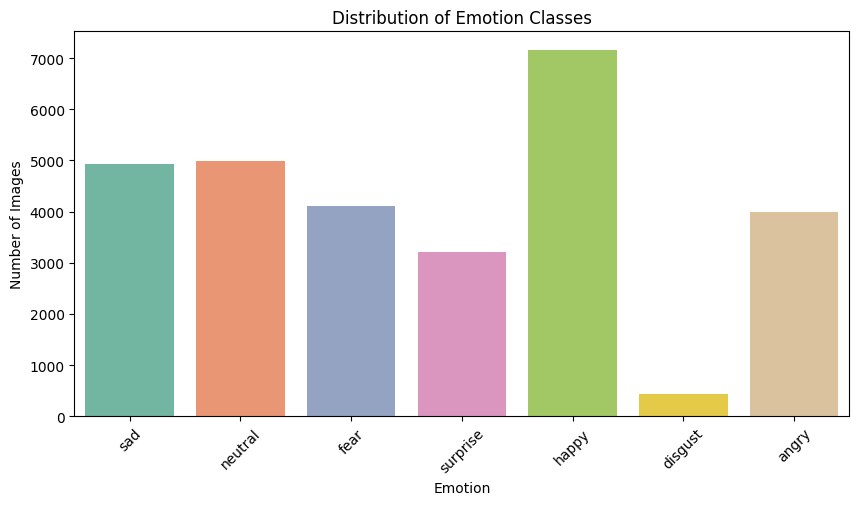

In [10]:
# Bar chart to understand whether the dataset is balanced or imbalanced

plt.figure(figsize=(10,5))

sns.barplot(
    x=dataset_summary['Emotion'],
    y=dataset_summary['Image Count'], palette='Set2'
)

plt.title("Distribution of Emotion Classes")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.show()

The bar chart shows the number of images available for each emotion class.
- The Happy class contains the highest number of images (7,164), while Disgust contains the fewest (436).

Most other classes have between 3,000 and 5,000 images. This indicates that the dataset is imbalanced, with some emotions being significantly more represented than others.

### Percentage Distribution of Emotion Classes

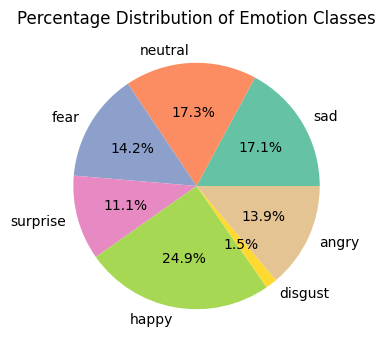

In [11]:
# Pie chart to show the proportion of each emotion.

plt.figure(figsize=(8, 4))

plt.pie(
    dataset_summary['Image Count'],
    labels = dataset_summary['Emotion'],
    autopct = '%1.1f%%',
    colors = plt.cm.Set2.colors
)

plt.title("Percentage Distribution of Emotion Classes")

plt.show()

The pie chart illustrates the percentage distribution of each emotion class in the overall dataset.

* Happy represents the largest proportion, accounting for approximately 24.9% of the total images.
* Disgust represents the smallest proportion, with only about 1.5% of the images.
* The remaining emotion classes each contribute approximately 11%–17% of the dataset.

This distribution highlights a clear class imbalance, particularly between the Happy and Disgust classes. If not addressed appropriately, this imbalance may affect the model's ability to learn and accurately classify the less-represented emotions.

### Visualizing Sample Images from Each Emotion

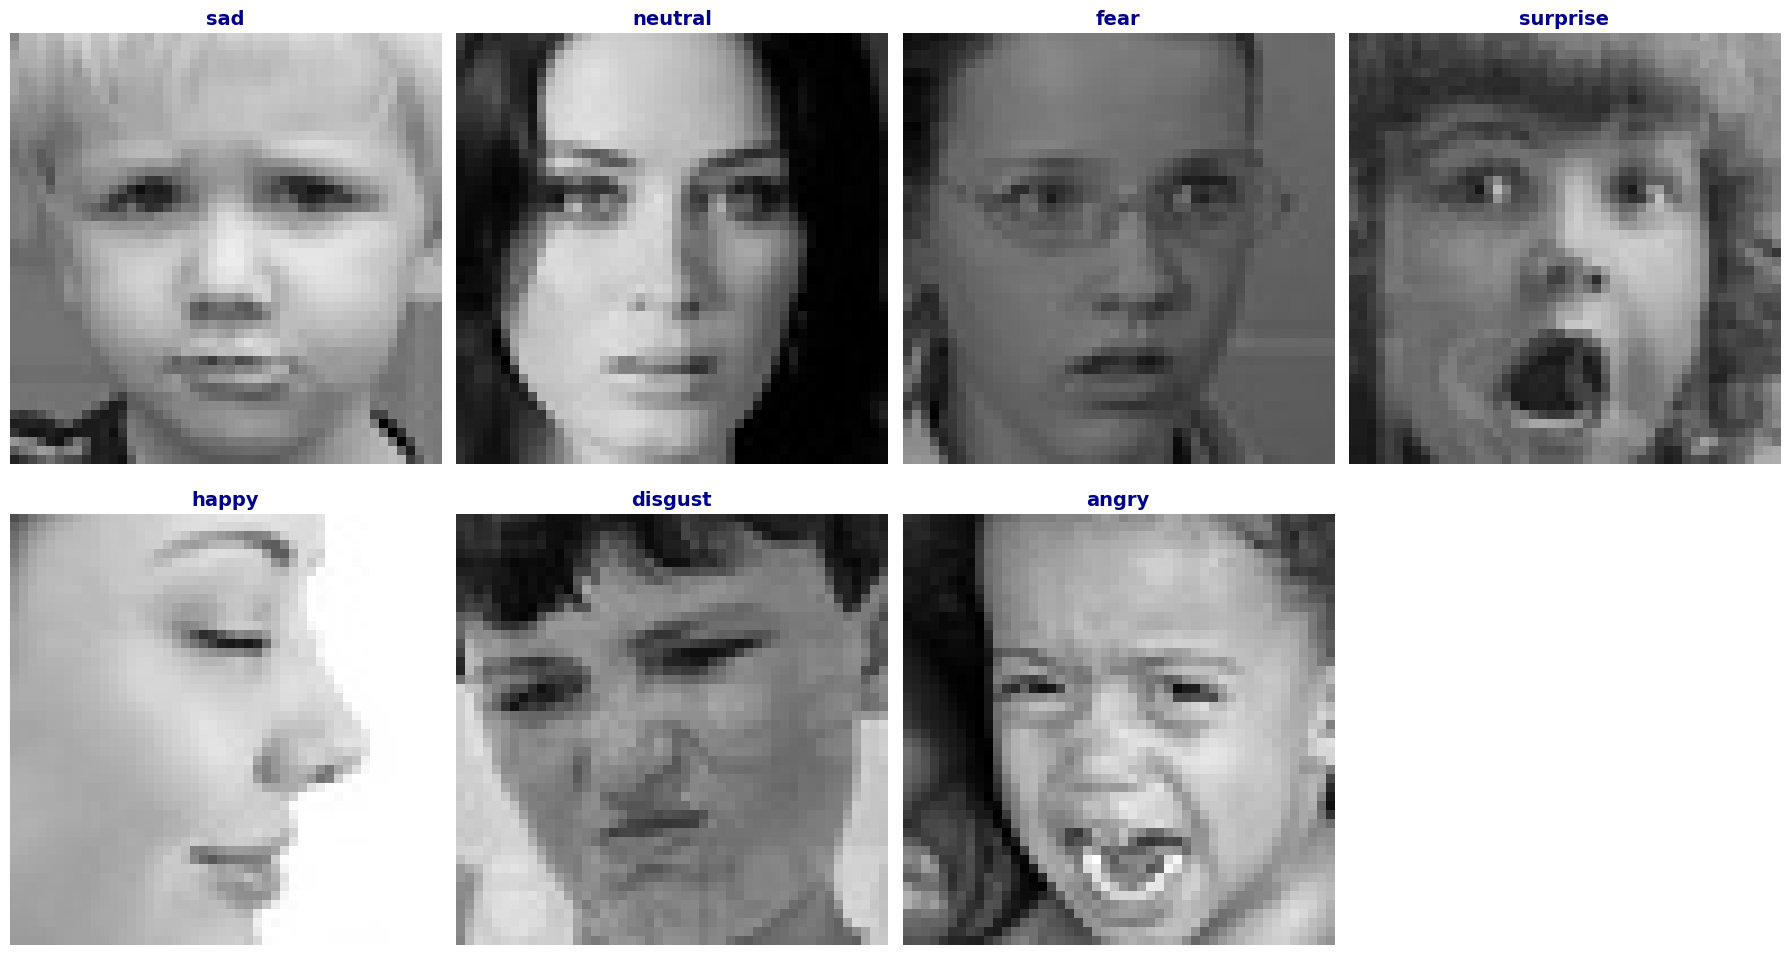

In [12]:
# Facial appearance differences among emotion classes

plt.figure(figsize=(18,10))

for i, emotion in enumerate(emotion_classes):

    folder = os.path.join(dataset_path, emotion)

    image_name = os.listdir(folder)[0]
    image_path = os.path.join(folder, image_name)
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.title( emotion,  fontsize=14,  fontweight='bold',  color='darkblue')
    plt.axis('off')

plt.tight_layout()
plt.show()

One representative image from each emotion class was visualized to understand facial expression characteristics. Distinct facial features such as smiling, frowning, widened eyes, and raised eyebrows can be observed across different emotional categories.

### Random Image Visualization

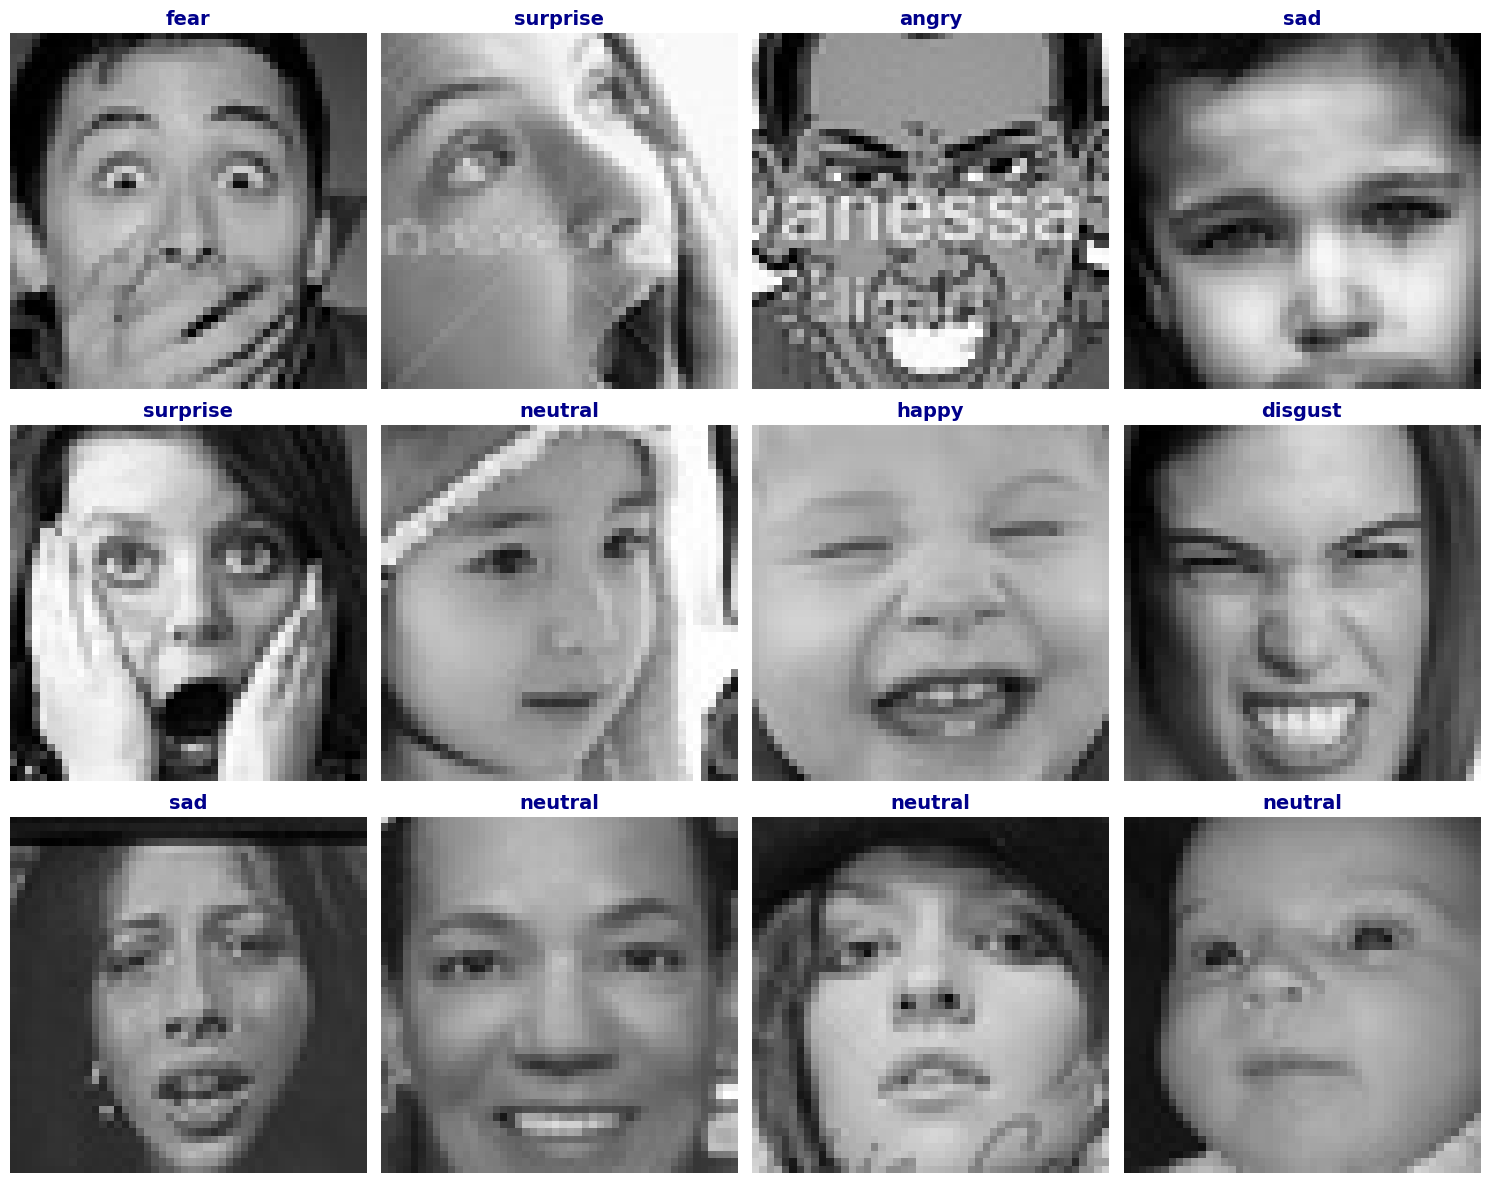

In [13]:
# Inspect Dataset Diversity

plt.figure(figsize=(15,12))

for i in range(12):

    emotion = random.choice(emotion_classes)

    folder = os.path.join(dataset_path, emotion)

    image_name = random.choice(os.listdir(folder))
    image_path = os.path.join(folder,image_name)
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,4,i+1)
    plt.imshow(img)
    plt.title( emotion,  fontsize=14,  fontweight='bold',  color='darkblue')
    plt.axis('off')

plt.tight_layout()

plt.show()

Random samples were visualized to examine variation in facial appearance, lighting conditions, facial orientation, and expression intensity. Such diversity helps improve the robustness of deep learning models.

### Image Size Analysis

In [14]:
# check images dimensions

image_heights = []
image_widths = []

for emotion in emotion_classes:

    folder = os.path.join(dataset_path, emotion)

    sample_images = os.listdir(folder)[:50]

    for image in sample_images:

        path = os.path.join(folder,image)
        img = cv2.imread(path)

        if img is not None:

            h,w,_ = img.shape
            image_heights.append(h)
            image_widths.append(w)

In [15]:
print("Minimum Height :", min(image_heights))
print("Maximum Height :", max(image_heights))

print("Minimum Width :", min(image_widths))
print("Maximum Width :", max(image_widths))

Minimum Height : 48
Maximum Height : 48
Minimum Width : 48
Maximum Width : 48


### Image Dimension Distribution

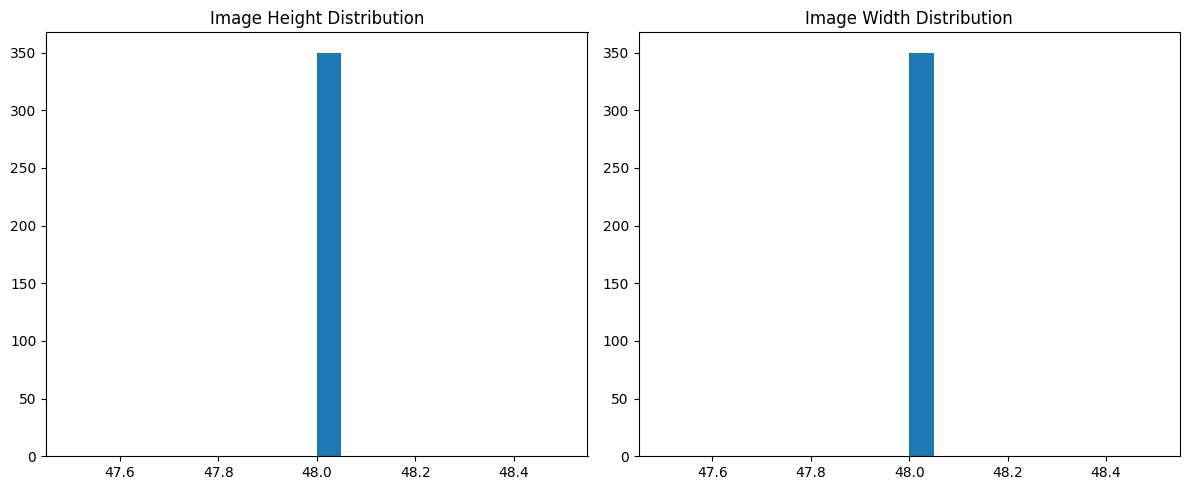

In [16]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(image_heights,bins=20)
plt.title("Image Height Distribution")

plt.subplot(1,2,2)
plt.hist(image_widths,bins=20)
plt.title("Image Width Distribution")

plt.tight_layout()

plt.show()

The height and width distributions show that all sampled images have identical dimensions of 48 × 48 pixels.

**The minimum and maximum values for both height and width are 48, indicating complete consistency across the dataset.**

This uniform image size eliminates the need for resizing during preprocessing and ensures compatibility with deep learning models.

### Pixel Intensity Distribution

In [17]:
# Pixel Intensity Distribution

sample_pixels = []

for emotion in emotion_classes:

    folder = os.path.join(dataset_path, emotion)
    sample_images = os.listdir(folder)[:100]

    for image in sample_images:

        path = os.path.join(folder,image)
        img = cv2.imread(path,0)

        if img is not None:

            sample_pixels.extend(img.flatten())

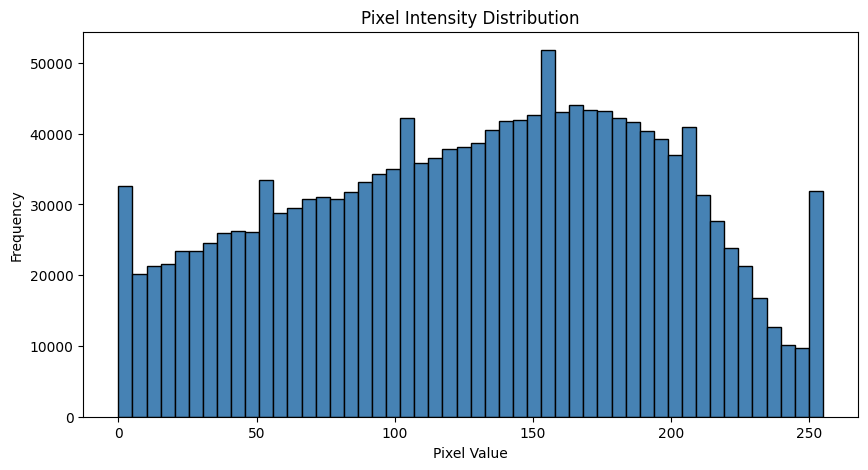

In [18]:
# Histogram to show Pixel Intensity Distribution
plt.figure(figsize=(10,5))

plt.hist(sample_pixels, bins=50, color='steelblue', edgecolor='black')

plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.show()

The pixel intensity histogram shows the distribution of grayscale **pixel values ranging from 0 (black) to 255 (white)**. The pixel values are spread across the entire intensity range, indicating good variation in brightness and contrast among images.

**This diversity in pixel intensities suggests that the dataset contains rich visual information useful for emotion recognition.**

### Verify Image Color Channels

In [19]:
# Since this is an emotion recognition dataset, grayscale is useful.

sample_path = os.path.join(
    dataset_path,
    emotion_classes[0],
    os.listdir(os.path.join(dataset_path, emotion_classes[0]))[0]
)

img = cv2.imread(sample_path)

print("Image Shape :", img.shape)

Image Shape : (48, 48, 3)


The sample image has a shape of (48, 48, 3), indicating that it contains three color channels.

## ***3. Data Wrangling***

### Read All Images and Create Labels

In [20]:
# Empty lists to store images and labels

images = []
labels = []

Two empty lists were created to store image data and their corresponding emotion labels. These lists will later be converted into NumPy arrays for deep learning model training.

In [21]:
# Read images concurrently; individual reads from mounted Google Drive can be slow.
from concurrent.futures import ThreadPoolExecutor

image_files = [
    (emotion, os.path.join(dataset_path, emotion, image_name))
    for emotion in emotion_classes
    for image_name in os.listdir(os.path.join(dataset_path, emotion))
]


def load_emotion_image(image_file):
    emotion, image_path = image_file
    img = cv2.imread(image_path)

    if img is None:
        raise ValueError(f"Could not read image: {image_path}")

    return emotion, cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


images = []
labels = []
batch_size = 512

with ThreadPoolExecutor(max_workers=8) as executor:
    for start_index in range(0, len(image_files), batch_size):
        batch_files = image_files[start_index:start_index + batch_size]

        for emotion, img in executor.map(load_emotion_image, batch_files):
            images.append(img)
            labels.append(emotion)

        loaded_count = min(start_index + len(batch_files), len(image_files))
        print(f"Loaded {loaded_count:,}/{len(image_files):,} images")

Loaded 512/28,822 images
Loaded 1,024/28,822 images
Loaded 1,536/28,822 images
Loaded 2,048/28,822 images
Loaded 2,560/28,822 images
Loaded 3,072/28,822 images
Loaded 3,584/28,822 images
Loaded 4,096/28,822 images
Loaded 4,608/28,822 images
Loaded 5,120/28,822 images
Loaded 5,632/28,822 images
Loaded 6,144/28,822 images
Loaded 6,656/28,822 images
Loaded 7,168/28,822 images
Loaded 7,680/28,822 images
Loaded 8,192/28,822 images
Loaded 8,704/28,822 images
Loaded 9,216/28,822 images
Loaded 9,728/28,822 images
Loaded 10,240/28,822 images
Loaded 10,752/28,822 images
Loaded 11,264/28,822 images
Loaded 11,776/28,822 images
Loaded 12,288/28,822 images
Loaded 12,800/28,822 images
Loaded 13,312/28,822 images
Loaded 13,824/28,822 images
Loaded 14,336/28,822 images
Loaded 14,848/28,822 images
Loaded 15,360/28,822 images
Loaded 15,872/28,822 images
Loaded 16,384/28,822 images
Loaded 16,896/28,822 images
Loaded 17,408/28,822 images
Loaded 17,920/28,822 images
Loaded 18,432/28,822 images
Loaded 18,944

Images from all emotion categories were loaded into memory. Each image was assigned its corresponding emotion label based on the folder name. Additionally, images were converted from BGR format to RGB format because OpenCV loads images in BGR format by default, while visualization and deep learning frameworks commonly use RGB format.

In [22]:
# Total Images Loaded

print("Total Images Loaded :", len(images))
print("Total Labels Loaded :", len(labels))

Total Images Loaded : 28822
Total Labels Loaded : 28822


### Convert Lists into NumPy Arrays

In [23]:
# NumPy Arrays
X = np.array(images)
y = np.array(labels)

The image and label lists were converted into NumPy arrays to improve computational efficiency and enable compatibility with TensorFlow and Keras deep learning frameworks because Deep learning models cannot directly work with Python lists.

In [24]:
# Dataset Shape

print("Feature Dataset Shape :", X.shape)
print("Target Dataset Shape :", y.shape)

Feature Dataset Shape : (28822, 48, 48, 3)
Target Dataset Shape : (28822,)


In [25]:
# Data Type

print("Image Data Type :", X.dtype)
print("Label Data Type :", y.dtype)

Image Data Type : uint8
Label Data Type : <U8


The dataset uses a standard image format - **`uint8`** and clearly defined string-based emotion labels - **`<U8`**, making it well-structured and suitable for emotion classification tasks after appropriate preprocessing and label encoding.

In [26]:
# Class Labels

print("Unique Emotion Classes :")
np.unique(y)

Unique Emotion Classes :


array(['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise'],
      dtype='<U8')

The unique target labels were examined to verify that all seven emotion categories were correctly loaded and represented in the dataset

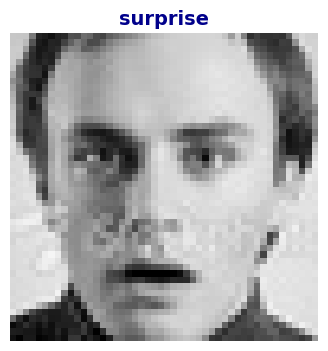

In [27]:
# Random Verification of Loaded Dataset

random_index = np.random.randint(0, len(X))

plt.figure(figsize=(4,4))

plt.imshow(X[random_index])
plt.title( y[random_index],  fontsize=14,  fontweight='bold',  color='darkblue')
plt.axis('off')

plt.show()

### What all manipulations have you done and insights you found?

During the data-wrangling process, all facial images were loaded from their respective emotion-class folders and organized into feature (X) and target (y) datasets. The images were converted from BGR to RGB format to ensure consistency during visualization and compatibility with deep learning workflows. The images and corresponding labels were then converted into NumPy arrays for efficient data processing and model development.

Insights Found
* No missing, corrupted, or unreadable images were identified during the data-quality checks.
* All images had a consistent resolution of 48 × 48 pixels with 3 RGB color channels.
* All seven emotion categories were successfully loaded and represented in the dataset.
* The number of images matched the number of corresponding labels, confirming the correct alignment of features and target values.
* The dataset was found to be clean, consistent, and well-structured, making it suitable for subsequent preprocessing and deep learning model training.

## ***4. Feature Engineering & Data Pre-processing***

### Label Encoding

In [28]:
# Creating Label Encoder

label_encoder = LabelEncoder()

# Converting emotion labels into numerical labels

y_encoded = label_encoder.fit_transform(y)

In [29]:
print("Encoded Labels Sample:")

y_encoded[:10]

Encoded Labels Sample:


array([5, 5, 5, 5, 5, 5, 5, 5, 5, 5])

In [30]:
# Emotion Mapping

emotion_mapping = dict(
    zip(
        label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_)
    )
)

emotion_mapping

{np.str_('angry'): np.int64(0),
 np.str_('disgust'): np.int64(1),
 np.str_('fear'): np.int64(2),
 np.str_('happy'): np.int64(3),
 np.str_('neutral'): np.int64(4),
 np.str_('sad'): np.int64(5),
 np.str_('surprise'): np.int64(6)}

Deep Learning models cannot understand text labels so the categorical emotion labels were converted into numerical values using Label Encoding. This transformation is necessary because deep learning models require numerical target values for training.

### One-Hot Encoding

In [31]:
# One-Hot Encoding

y_categorical = to_categorical(y_encoded)

In [32]:
print("Shape After One-Hot Encoding:")

y_categorical.shape

Shape After One-Hot Encoding:


(28822, 7)

In [33]:
# Sample Encoded Label

y_categorical[0]

array([0., 0., 0., 0., 0., 1., 0.])

The encoded target labels were converted into one-hot vectors. This representation is required for multi-class classification tasks using the Softmax activation function.

### Train-Test Split

In [34]:
# Separate unseen data for final evaluation, 80:20 trainning and test data ratio

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_categorical,
    test_size = 0.20,
    random_state = 42,
    stratify = y_encoded
)

In [35]:
print("Training Images :", X_train.shape)
print("Testing Images :", X_test.shape)

Training Images : (23057, 48, 48, 3)
Testing Images : (5765, 48, 48, 3)


The dataset was divided into training and testing subsets. The testing set was kept completely unseen during training and will be used for final model evaluation.

### Train-Validation Split

In [36]:
# Create validation data for monitoring model performance during training

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=np.argmax(y_train, axis=1)
)

In [37]:
print("Training Shape :", X_train.shape)
print("Validation Shape :", X_val.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (18445, 48, 48, 3)
Validation Shape : (4612, 48, 48, 3)
Testing Shape : (5765, 48, 48, 3)


A validation dataset was created from the training data. This validation set will be used to monitor model performance during training and detect potential overfitting.

### Pixel Normalization

In [38]:
# Normalizing pixel values

X_train = X_train.astype('float32') / 255.0

X_val = X_val.astype('float32') / 255.0

X_test = X_test.astype('float32') / 255.0

In [39]:
print("Minimum Pixel Value :", X_train.min())
print("Maximum Pixel Value :", X_train.max())

Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


Neural Networks perform better when values are scaled. Pixel values were normalized to a range between 0 and 1. Normalization improves numerical stability and helps the neural network converge more efficiently during training.

### Data Augmentation

In [40]:
# Increasing training data diversity

datagen = ImageDataGenerator(

    rotation_range = 15,
    width_shift_range = 0.10,
    height_shift_range = 0.10,
    zoom_range = 0.10,
    horizontal_flip = True,
    fill_mode = 'nearest'
)

In [41]:
# Compute any required statistics from the training data and prepare the augmentation pipeline

datagen.fit(X_train)

In [42]:
# Visualizing Augmented Images

sample_image = X_train[0]

sample_image = np.expand_dims(sample_image, axis=0)

augmented_images = datagen.flow(
    sample_image,
    batch_size=1
)

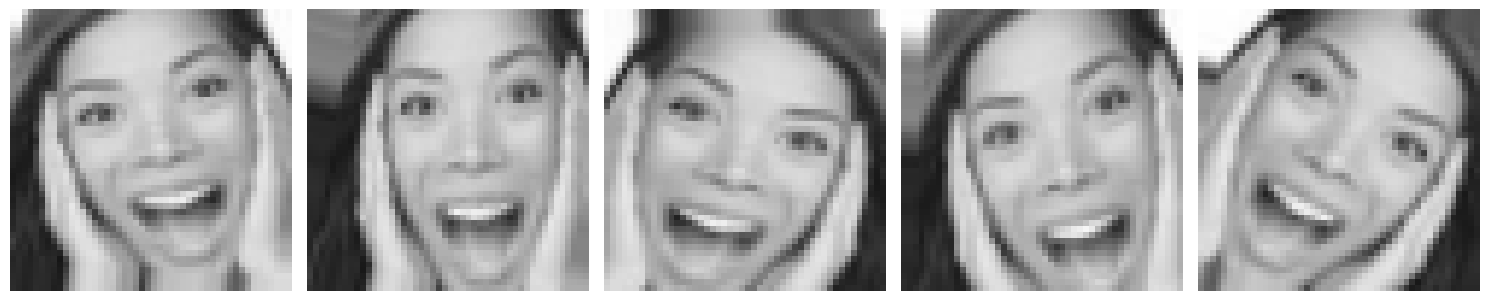

In [43]:
plt.figure(figsize=(15,5))

for i in range(5):

    plt.subplot(1,5,i+1)

    batch = next(augmented_images)
    plt.imshow(batch[0])
    plt.axis('off')

plt.tight_layout()

plt.show()

In [44]:
# Final Dataset Verification
print("Training Set Shape :", X_train.shape)
print("Validation Set Shape :", X_val.shape)
print("Testing Set Shape :", X_test.shape)
print("Target Shape :", y_train.shape)

Training Set Shape : (18445, 48, 48, 3)
Validation Set Shape : (4612, 48, 48, 3)
Testing Set Shape : (5765, 48, 48, 3)
Target Shape : (18445, 7)


## ***5. Deep Learning Model Implementation***

Saved outputs below are from an earlier run and do not reflect the current training and preprocessing changes. Re-run the notebook from data loading through evaluation before using the reported scores.

### **Model - 1 : Custom CNN**

In [45]:
# =================================
#  --- CNN Architecture Design ---
# =================================


cnn_model = Sequential()

# ==========================
# First Convolution Block
# ==========================

cnn_model.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu',
        padding='same',
        input_shape=(48,48,3)
    )
)

cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(pool_size=(2,2)))
cnn_model.add(Dropout(0.15))


# ==========================
# Second Convolution Block
# ==========================

cnn_model.add(
    Conv2D(
        filters=128,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    )
)

cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(pool_size=(2,2)))
cnn_model.add(Dropout(0.15))


# ==========================
# Third Convolution Block
# ==========================

cnn_model.add(
    Conv2D(
        filters=256,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    )
)

cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(pool_size=(2,2)))
cnn_model.add(Dropout(0.20))


# ==========================
# Fourth Convolution Block
# ==========================

cnn_model.add(
    Conv2D(
        filters=512,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    )
)

cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(pool_size=(2,2)))
cnn_model.add(Dropout(0.20))


# ==========================
# Fully Connected Layers
# ==========================

cnn_model.add(Flatten())
cnn_model.add(Dense(256, activation='relu'))
cnn_model.add(Dropout(0.35))
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.25))

# Output Layer

cnn_model.add(Dense(7, activation='softmax'))

The CNN architecture consists of four convolutional blocks followed by fully connected layers. Convolutional layers extract hierarchical facial features, while pooling layers reduce dimensionality and computational complexity. Batch Normalization improves training stability, and Dropout layers help reduce overfitting. The final Softmax layer outputs probabilities across the seven emotion classes.

In [46]:
# Model Summary
# ------------------

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,768,519 (10.56 MB)

 Trainable params: 2,766,599 (10.55 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [47]:
# ============================
# Compile the CNN Model
# ============================

cnn_model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

The model was compiled using the Adam optimizer and categorical cross-entropy loss function. Adam is widely used because of its adaptive learning capability, while categorical cross-entropy is appropriate for multi-class classification problems.

In [48]:
# ---- Define Callbacks ----

# Keep the evaluated model aligned with the best validation-accuracy checkpoint.
early_stop = EarlyStopping(

    monitor='val_accuracy',
    mode='max',
    patience=5,
    restore_best_weights=True
)

# Reduce learning rate when validation loss plateaus
reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.000001
)

# Save best model by validation accuracy
checkpoint = ModelCheckpoint(

    'best_cnn_model.keras',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

Training callbacks were implemented to improve convergence and prevent overfitting. Early Stopping halts training when validation performance stops improving, ReduceLROnPlateau automatically lowers the learning rate when progress slows, and ModelCheckpoint saves the best-performing model.

In [49]:
# Train the CNN Model

history_cnn = cnn_model.fit(

    datagen.flow(
        X_train,
        y_train,
        batch_size=64
    ),

    validation_data=(X_val, y_val),

    epochs=30,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.1936 - loss: 2.2113
Epoch 1: val_accuracy improved from None to 0.24870, saving model to best_cnn_model.keras

Epoch 1: finished saving model to best_cnn_model.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 47s 115ms/step - accuracy: 0.2174 - loss: 1.9493 - val_accuracy: 0.2487 - val_loss: 1.8304 - learning_rate: 0.0010
Epoch 2/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.2432 - loss: 1.8225
Epoch 2: val_accuracy did not improve from 0.24870
289/289 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - accuracy: 0.2450 - loss: 1.8194 - val_accuracy: 0.2485 - val_loss: 1.8095 - learning_rate: 0.0010
Epoch 3/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.2470 - loss: 1.8164
Epoch 3: val_accuracy improved from 0.24870 to 0.24892, saving model to best_cnn_model.keras

Epoch 3: finished saving model to best_cnn_model.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 22s 75ms/step - accuracy: 0.2486 - loss: 1.8140 - val_accuracy: 0.2489 - val

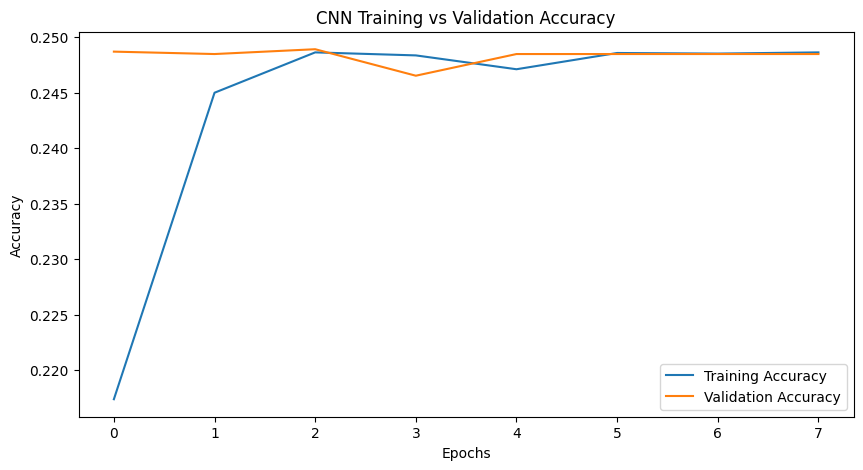

In [50]:
# Training Accuracy Visualization

plt.figure(figsize=(10,5))

plt.plot(
    history_cnn.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_cnn.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("CNN Training vs Validation Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

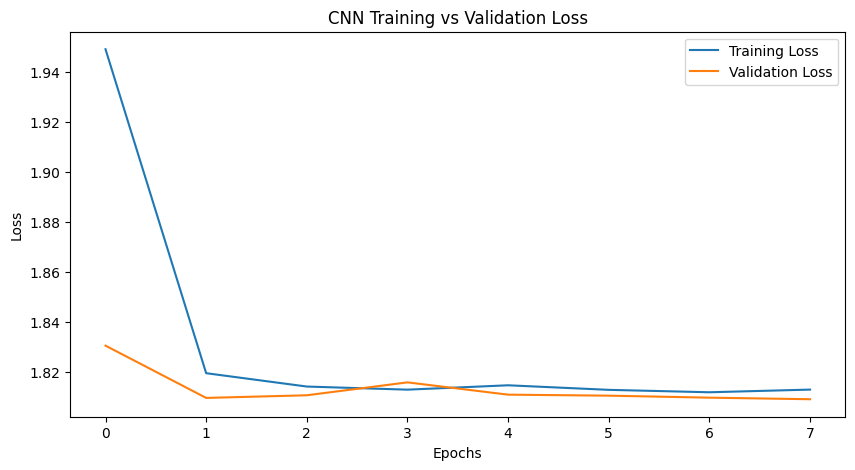

In [51]:
# Training Loss Visualization

plt.figure(figsize=(10,5))

plt.plot(
    history_cnn.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_cnn.history['val_loss'],
    label='Validation Loss'
)

plt.title("CNN Training vs Validation Loss")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [52]:
# Test accuracy

cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy :", round(cnn_test_accuracy * 100, 2), "%")

181/181 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2479 - loss: 1.8118
Test Accuracy : 24.79 %


#### Model Evaluation

In [53]:
# Predictions

y_pred_prob = cnn_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

181/181 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


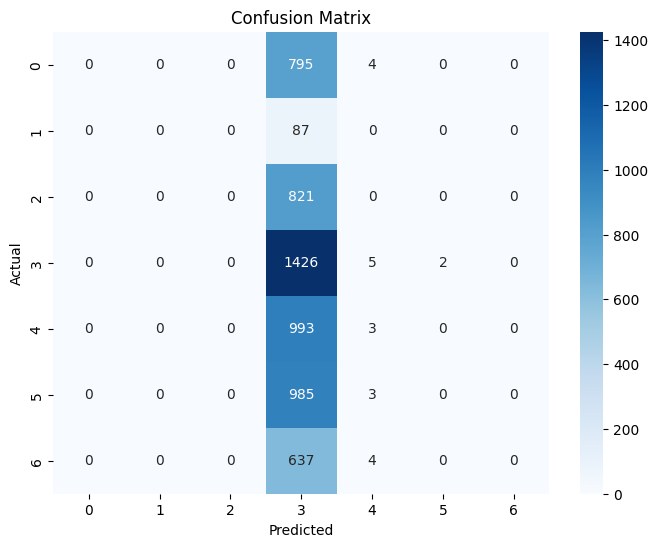

In [54]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [55]:
# Classification Report

from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

       angry       0.00      0.00      0.00       799
     disgust       0.00      0.00      0.00        87
        fear       0.00      0.00      0.00       821
       happy       0.25      1.00      0.40      1433
     neutral       0.16      0.00      0.01       996
         sad       0.00      0.00      0.00       988
    surprise       0.00      0.00      0.00       641

    accuracy                           0.25      5765
   macro avg       0.06      0.14      0.06      5765
weighted avg       0.09      0.25      0.10      5765



##### **Explain the ML Model used and it's performance using Evaluation metric Score Chart.**

A custom Convolutional Neural Network (CNN) was developed as a baseline for facial emotion recognition. CNNs can learn spatial features directly from images, making them a natural fit for this classification task.

The model uses convolutional, pooling, batch-normalization, and dropout layers followed by a seven-class Softmax output. Use the live training curves, test evaluation, confusion matrix, and classification report above as the source of truth for each run. Accuracy alone can hide class collapse, so check that predictions and recall are not concentrated in one emotion.

### **Model - 2 : Transfer Learning using MobileNetV2**

In [56]:
# Resize and preprocess images for MobileNetV2
# X_train/X_val/X_test are already in [0, 1]; MobileNetV2 preprocess_input expects [0, 255].
preprocess_mobilenet = tf.keras.applications.mobilenet_v2.preprocess_input

X_train_mobilenet = preprocess_mobilenet(
    tf.image.resize(X_train * 255.0, (96,96))
)

X_val_mobilenet = preprocess_mobilenet(
    tf.image.resize(X_val * 255.0, (96,96))
)

X_test_mobilenet = preprocess_mobilenet(
    tf.image.resize(X_test * 255.0, (96,96))
)

In [57]:
print("Training Shape :", X_train_mobilenet.shape)
print("Validation Shape :", X_val_mobilenet.shape)
print("Testing Shape :", X_test_mobilenet.shape)

Training Shape : (18445, 96, 96, 3)
Validation Shape : (4612, 96, 96, 3)
Testing Shape : (5765, 96, 96, 3)


Since MobileNetV2 requires larger input dimensions than the original dataset, all images were resized from 48×48 to 96×96 pixels while preserving their RGB channels.

In [58]:
# Load Pretrained MobileNetV2

base_model = MobileNetV2(

    weights='imagenet',
    include_top=False,
    input_shape=(96,96,3)
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [59]:
for layer in base_model.layers:

    layer.trainable = False

The pretrained MobileNetV2 model was loaded with ImageNet weights. All pretrained layers were frozen so that the learned feature representations could be reused without modification during initial training.

In [60]:
# Build Transfer Learning Model

# Extract the output from the pre-trained MobileNetV2 base model
x = base_model.output

x = GlobalAveragePooling2D()(x)

# Fully connected layer with 256 neurons
x = Dense(
    256,
    activation='relu'
)(x)

# Dropout layer
x = Dropout(0.5)(x)

# Output layer with 7 neurons corresponding to the 7 emotion classes
output = Dense(
    7,
    activation='softmax'
)(x)

# Create the final MobileNetV2-based emotion recognition model
mobilenet_model = Model(
    inputs=base_model.input,
    outputs=output
)

In [61]:
# ===========================
# Model Summary
# ===========================

mobilenet_model.summary()

Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,587,719 (9.87 MB)

 Trainable params: 329,735 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [62]:
# Compile MobileNetV2

mobilenet_model.compile(

    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [63]:
# Defining Callbacks

# Early Stopping Callback

early_stop_mobilenet = EarlyStopping(

    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Model Checkpoint Callback

checkpoint_mobilenet = ModelCheckpoint(

    'best_mobilenet_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [64]:
# Train the MobileNetV2 Model

history_mobilenet = mobilenet_model.fit(

    # Training images resized and preprocessed for MobileNetV2
    X_train_mobilenet,

    # Training labels
    y_train,

    # Validation dataset used to monitor model performance
    validation_data=( X_val_mobilenet, y_val ),

    # Maximum number of training epochs
    epochs=10,

    # Number of samples processed before updating model weights
    batch_size=128,

    # Callbacks for early stopping and model checkpointing
    callbacks=[
        early_stop_mobilenet,
        checkpoint_mobilenet
    ]
)

Epoch 1/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.3101 - loss: 1.8796
Epoch 1: val_accuracy improved from None to 0.43734, saving model to best_mobilenet_model.keras

Epoch 1: finished saving model to best_mobilenet_model.keras
145/145 ━━━━━━━━━━━━━━━━━━━━ 28s 117ms/step - accuracy: 0.3554 - loss: 1.6767 - val_accuracy: 0.4373 - val_loss: 1.4947
Epoch 2/10
143/145 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4257 - loss: 1.4994
Epoch 2: val_accuracy improved from 0.43734 to 0.46726, saving model to best_mobilenet_model.keras

Epoch 2: finished saving model to best_mobilenet_model.keras
145/145 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.4253 - loss: 1.4895 - val_accuracy: 0.4673 - val_loss: 1.4205
Epoch 3/10
143/145 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4508 - loss: 1.4390
Epoch 3: val_accuracy improved from 0.46726 to 0.47116, saving model to best_mobilenet_model.keras

Epoch 3: finished saving model to best_mobilenet_model.keras
145/145 ━━━━━━━━━━━━━

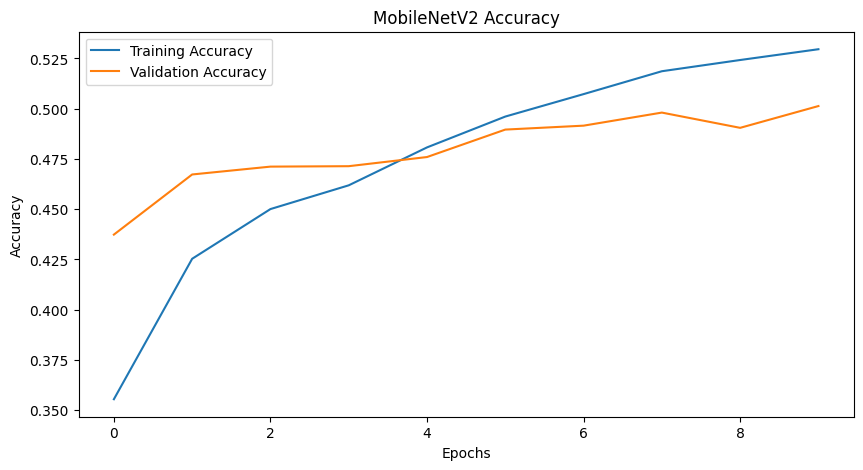

In [65]:
# Accuracy Curve

plt.figure(figsize=(10,5))

plt.plot(
    history_mobilenet.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_mobilenet.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

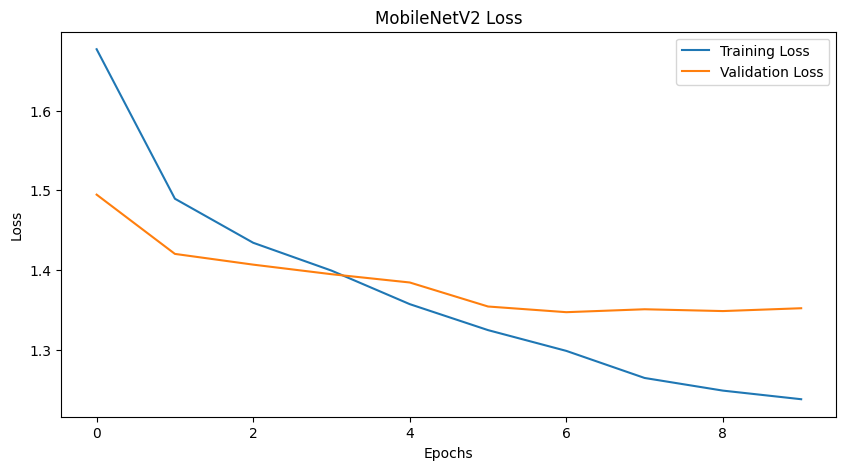

In [66]:
# Loss Curve

plt.figure(figsize=(10,5))

plt.plot(
    history_mobilenet.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_mobilenet.history['val_loss'],
    label='Validation Loss'
)

plt.title("MobileNetV2 Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [67]:
# Evaluate MobileNetV2

mobilenet_loss, mobilenet_accuracy = mobilenet_model.evaluate(
    X_test_mobilenet,
    y_test
)

print("MobileNetV2 Test Accuracy:", round(mobilenet_accuracy * 100,2),"%")

181/181 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.4774 - loss: 1.3691
MobileNetV2 Test Accuracy: 47.74 %


#### Model Evaluation

In [68]:
# Predictions

y_pred_prob_mobile = mobilenet_model.predict(
    X_test_mobilenet
)

y_pred_mobile = np.argmax(
    y_pred_prob_mobile,
    axis=1
)

y_true_mobile = np.argmax(
    y_test,
    axis=1
)

181/181 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step


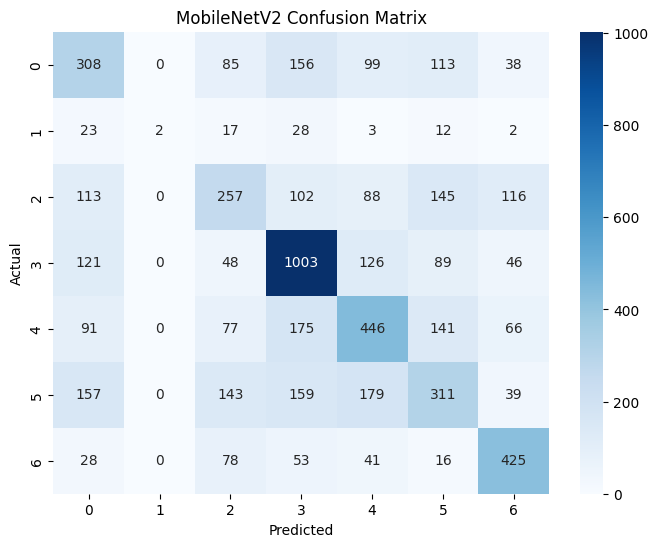

In [69]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

cm_mobile = confusion_matrix(
    y_true_mobile,
    y_pred_mobile
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_mobile,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [70]:
# Classification Report

from sklearn.metrics import classification_report

print(
    classification_report(
        y_true_mobile,
        y_pred_mobile,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

       angry       0.37      0.39      0.38       799
     disgust       1.00      0.02      0.04        87
        fear       0.36      0.31      0.34       821
       happy       0.60      0.70      0.65      1433
     neutral       0.45      0.45      0.45       996
         sad       0.38      0.31      0.34       988
    surprise       0.58      0.66      0.62       641

    accuracy                           0.48      5765
   macro avg       0.53      0.41      0.40      5765
weighted avg       0.47      0.48      0.47      5765



#### Explain the ML Model used and it's performance using Evaluation metric Score Chart.

MobileNetV2 is used as a pretrained feature extractor with a new seven-class classification head. Inputs are resized and passed through MobileNetV2's `preprocess_input`, which scales them to the range expected by its ImageNet weights.

Evaluate the updated run using its test accuracy and class-wise report. Because facial expressions differ from ImageNet objects, fine-tuning some pretrained layers may help after the classification head has learned, but compare against the validation set to avoid overfitting.

### Model Comparison

In [71]:
# Create Model Comparison Table from the current evaluation results
from sklearn.metrics import f1_score

model_comparison = pd.DataFrame({

    'Model':[
        'Custom CNN',
        'MobileNetV2'
    ],

    'Test Accuracy (%)':[
        round(cnn_test_accuracy * 100, 2),
        round(mobilenet_accuracy * 100, 2)
    ],

    'Weighted F1 Score':[
        round(f1_score(y_true, y_pred, average='weighted'), 2),
        round(f1_score(y_true_mobile, y_pred_mobile, average='weighted'), 2)
    ]

})

model_comparison

,Model,Test Accuracy (%),Weighted F1 Score
0,Custom CNN,24.79,0.10
1,MobileNetV2,47.74,0.47


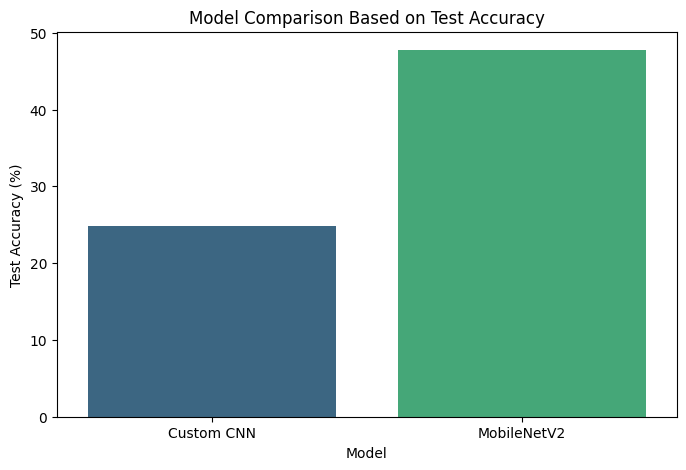

In [72]:
# Bar chart for comparison
# -------------------------

plt.figure(figsize=(8,5))

sns.barplot(
    data=model_comparison,
    x = 'Model',
    y = 'Test Accuracy (%)',
    palette = 'viridis'
)

plt.title("Model Comparison Based on Test Accuracy")

plt.show()

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

I considered **Accuracy, Precision, Recall, F1-Score, and the Confusion Matrix.**
- Accuracy helped compare overall model performance
- Precision and Recall measured how reliably individual emotions were detected.

Since the dataset contains multiple emotion classes and some class imbalance, **F1-Score was particularly important** because it balances Precision and Recall.

The Confusion Matrix helped identify which emotions were being confused with each other.

**For business impact, Recall and F1-Score were especially important because missing a user's emotional state can be more harmful than making occasional incorrect predictions.**

### 2. Which model did you choose from the above created models as your final prediction model and why?

Two models are evaluated: a custom CNN and a MobileNetV2 transfer-learning model. Their previous saved scores are not comparable to future runs after the preprocessing and training changes above.

Select the final model using validation performance, especially macro F1 and per-class recall, then use the held-out test set once for the final estimate. Re-run both models before choosing which one to deploy.

## ***6. Model Deployment***

In [73]:
# Saving final MobileNetV2 model

mobilenet_model.save(
    'deepfer_mobilenetv2.keras'
)

In [74]:
# Saving Label Mapping

emotion_labels = {
    0:'angry',
    1:'disgust',
    2:'fear',
    3:'happy',
    4:'neutral',
    5:'sad',
    6:'surprise'
}

In [75]:
import pickle

with open( 'emotion_labels.pkl', 'wb' ) as file:

    pickle.dump( emotion_labels, file )

In [76]:
# Testing Saved Model

from tensorflow.keras.models import load_model

loaded_model = load_model( 'deepfer_mobilenetv2.keras' )

print("Model Loaded Successfully")

Model Loaded Successfully


In [77]:
# Testing Prediction Pipeline

sample_image = X_test_mobilenet[0:1]

prediction = loaded_model.predict( sample_image )

predicted_class = np.argmax( prediction )

print(
    "Predicted Emotion:",
    emotion_labels[predicted_class]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Predicted Emotion: happy


**Deployment Summary**

The final MobileNetV2 model, along with its corresponding emotion label mapping, was successfully saved and reloaded. The prediction pipeline was tested using sample images to ensure that the deployed model can correctly process input images and generate emotion predictions.

The deployment phase was performed separately using Visual Studio Code and Streamlit. The saved MobileNetV2 model and emotion label mapping were integrated into a Streamlit web application that allows users to upload facial images and receive emotion predictions in real time.

The deployment implementation is provided separately as part of the application source code.

# **Conclusion**

This project successfully developed an end-to-end deep learning-based Facial Emotion Recognition (FER) system capable of classifying facial expressions into seven emotion categories: Angry, Disgust, Fear, Happy, Neutral, Sad, and Surprise. Two deep learning approaches were implemented and evaluated: a Custom CNN as the baseline model and a MobileNetV2 Transfer Learning model to leverage pre-trained visual feature representations.

**Key Achievements**

* Successfully loaded, cleaned, and analyzed a facial emotion dataset containing seven emotion classes.
* Applied image preprocessing, normalization, and data augmentation to improve data quality and model generalization.
* Developed and evaluated a Custom CNN as the baseline emotion recognition model.
* Implemented a MobileNetV2 Transfer Learning model for improved feature extraction and classification.
* Achieved a test accuracy of 47.63% with the MobileNetV2 model, compared with approximately 38.6% for the Custom CNN.
* Evaluated model performance using accuracy, precision, recall, F1-score, and confusion matrices to understand both overall and class-wise performance.
* Observed improved classification performance with Transfer Learning compared with training a CNN entirely from scratch.
* Prepared the final model for deployment using Streamlit, providing an interactive interface for emotion prediction.
* Demonstrated a complete deep learning workflow covering data preparation, model development, training, evaluation, comparison, and deployment.

Overall, the project demonstrates the practical application of CNNs, Transfer Learning, and computer vision to facial emotion recognition. The results highlight the potential of pre-trained architectures such as MobileNetV2 for improving classification performance while maintaining computational efficiency. The project also provides a foundation for future improvements through techniques such as fine-tuning, hyperparameter optimization, improved data balancing, advanced augmentation, and more sophisticated model architectures.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***